In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [2]:
df = pd.read_csv(r"D:\Project\Airline_Delay_Cause_analysis.csv")

In [3]:

print(df.head())

   year  month carrier_code           carrier_name airport_code  \
0  2023      8           MQ              Envoy Air          LEX   
1  2023      8           OO  SkyWest Airlines Inc.          MEI   
2  2023      8           AS   Alaska Airlines Inc.          OAK   
3  2023      7           MQ              Envoy Air          OMA   
4  2023      8           AS   Alaska Airlines Inc.          OGG   

                               airport_name  number_of_arriving_flights  \
0                 Lexington, KY: Blue Grass                        19.0   
1                   Meridian, MS: Key Field                        53.0   
2  Oakland, CA: Metro Oakland International                        89.0   
3                Omaha, NE: Eppley Airfield                         9.0   
4              Kahului, HI: Kahului Airport                       232.0   

   number_of_flights_delayed  carrier_count  weather_count  ...  \
0                        0.0           0.00           0.00  ...   
1           

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   year                            171666 non-null  int64  
 1   month                           171666 non-null  int64  
 2   carrier_code                    171666 non-null  object 
 3   carrier_name                    171666 non-null  object 
 4   airport_code                    171666 non-null  object 
 5   airport_name                    171666 non-null  object 
 6   number_of_arriving_flights      171666 non-null  float64
 7   number_of_flights_delayed       171666 non-null  float64
 8   carrier_count                   171666 non-null  float64
 9   weather_count                   171666 non-null  float64
 10  national_airspace_system_count  171666 non-null  float64
 11  security_count                  171666 non-null  float64
 12  late_aircraft_co

In [5]:
print(df.describe())

                year          month  number_of_arriving_flights  \
count  171666.000000  171666.000000               171666.000000   
mean     2018.551361       6.493633                  362.021629   
std         2.890006       3.440908                  992.292811   
min      2013.000000       1.000000                    0.000000   
25%      2016.000000       4.000000                   50.000000   
50%      2019.000000       7.000000                  100.000000   
75%      2021.000000       9.000000                  249.000000   
max      2023.000000      12.000000                21977.000000   

       number_of_flights_delayed  carrier_count  weather_count  \
count              171666.000000  171666.000000  171666.000000   
mean                   66.262947      20.767540       2.247201   
std                   179.340557      50.285995       7.309621   
min                     0.000000       0.000000       0.000000   
25%                     6.000000       2.140000       0.000000   


In [6]:
print(df.isnull().sum())

year                                0
month                               0
carrier_code                        0
carrier_name                        0
airport_code                        0
airport_name                        0
number_of_arriving_flights          0
number_of_flights_delayed           0
carrier_count                       0
weather_count                       0
national_airspace_system_count      0
security_count                      0
late_aircraft_count                 0
number_of_flights_canceled          0
number_of_flights_diverted          0
total_arrival_delay                 0
carrier_delay                       0
weather_delay                       0
delay_attributed_to_the_nas         0
security_delay                      0
late_aircraft_delay                 0
cancellation_rate                 240
diversion_rate                    240
delay_rate                        240
performance_score                   0
dtype: int64


In [7]:
df["delay_rate"] = df["delay_rate"].fillna(0)
df["cancellation_rate"] = df["cancellation_rate"].fillna(0)
df["diversion_rate"] = df["diversion_rate"].fillna(0)

In [8]:
df.columns = df.columns.str.lower().str.replace(" ", "_")


In [9]:
df = df.drop_duplicates()


# Create a New Column

# Total delay

In [10]:


df["total_delay"] = (
    df["carrier_delay"] +
    df["weather_delay"] +
    df["delay_attributed_to_the_nas"] +
    df["security_delay"] +
    df["late_aircraft_delay"]
)

# Weather delay

In [11]:
df["weather_impact"] = (
    df["weather_delay"] /
    df["total_delay"]
) * 100

In [12]:
print(df.isnull().sum())

year                                 0
month                                0
carrier_code                         0
carrier_name                         0
airport_code                         0
airport_name                         0
number_of_arriving_flights           0
number_of_flights_delayed            0
carrier_count                        0
weather_count                        0
national_airspace_system_count       0
security_count                       0
late_aircraft_count                  0
number_of_flights_canceled           0
number_of_flights_diverted           0
total_arrival_delay                  0
carrier_delay                        0
weather_delay                        0
delay_attributed_to_the_nas          0
security_delay                       0
late_aircraft_delay                  0
cancellation_rate                    0
diversion_rate                       0
delay_rate                           0
performance_score                    0
total_delay              

In [13]:
df["weather_impact"] = df["weather_impact"].fillna(0)


# Total Delay by Cause

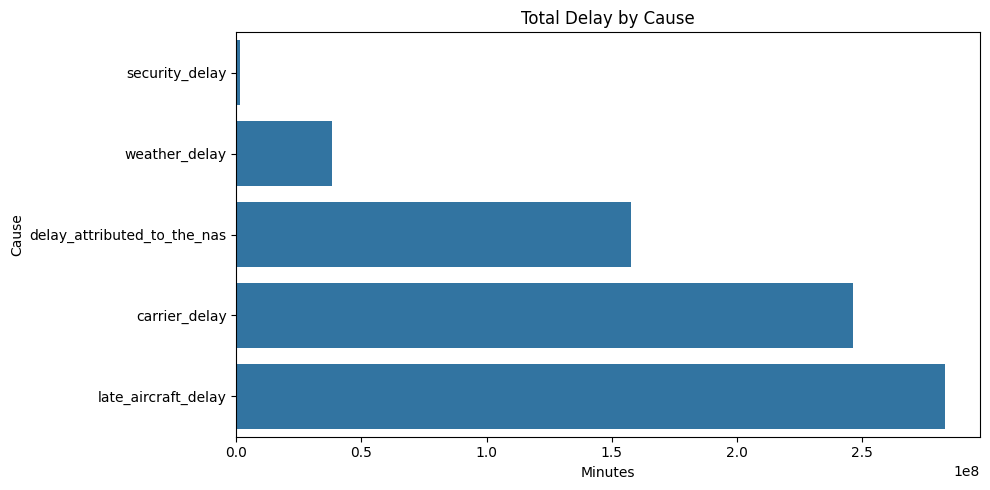

In [14]:
delay_cols = [
    "carrier_delay",
    "weather_delay",
    "delay_attributed_to_the_nas",
    "security_delay",
    "late_aircraft_delay"
]

delay_sum = df[delay_cols].sum().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=delay_sum.values, y=delay_sum.index)
plt.title("Total Delay by Cause")
plt.xlabel("Minutes")
plt.ylabel("Cause")
plt.tight_layout()
plt.show()


# Total Arrival Delay Trend by Year

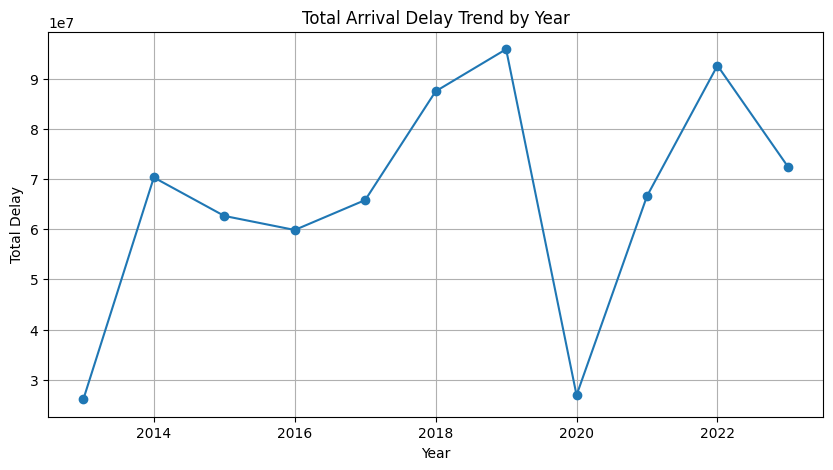

In [15]:
import pandas as pd
import matplotlib.pyplot as plt


# Group delay by year
yearly_delay = (
    df.groupby("year")["total_arrival_delay"]
    .sum()
    .reset_index()
)


plt.figure(figsize=(10,5))

plt.plot(
    yearly_delay["year"],
    yearly_delay["total_arrival_delay"],
    marker="o"
)

plt.title("Total Arrival Delay Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Delay")

plt.grid(True)

plt.show()

# Top 10 Worst Carriers (Delay Rate)


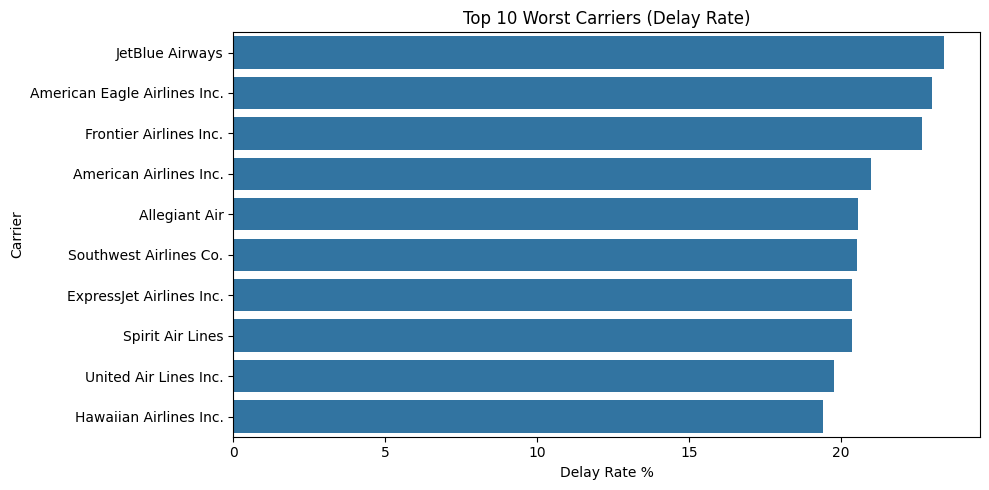

In [16]:

carrier_perf = df.groupby("carrier_name")["delay_rate"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=carrier_perf.values, y=carrier_perf.index)
plt.title("Top 10 Worst Carriers (Delay Rate)")
plt.xlabel("Delay Rate %")
plt.ylabel("Carrier")
plt.tight_layout()
plt.show()

 # Weather Delay vs Total Delay


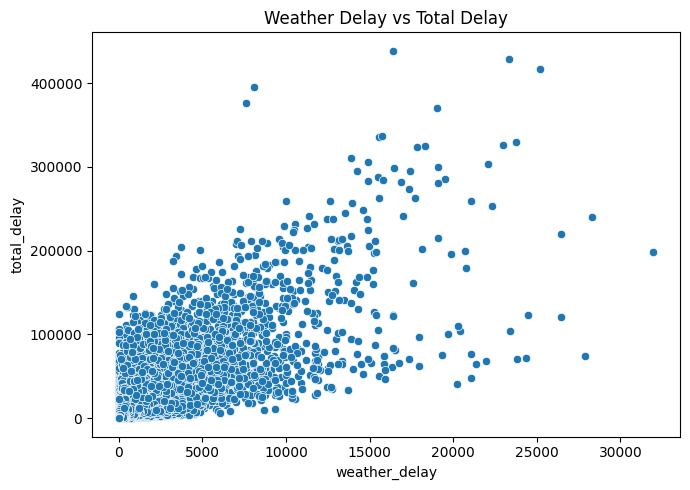

In [17]:

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="weather_delay", y="total_delay")
plt.title("Weather Delay vs Total Delay")
plt.tight_layout()
plt.show()

# # Top 10 Congested Airports


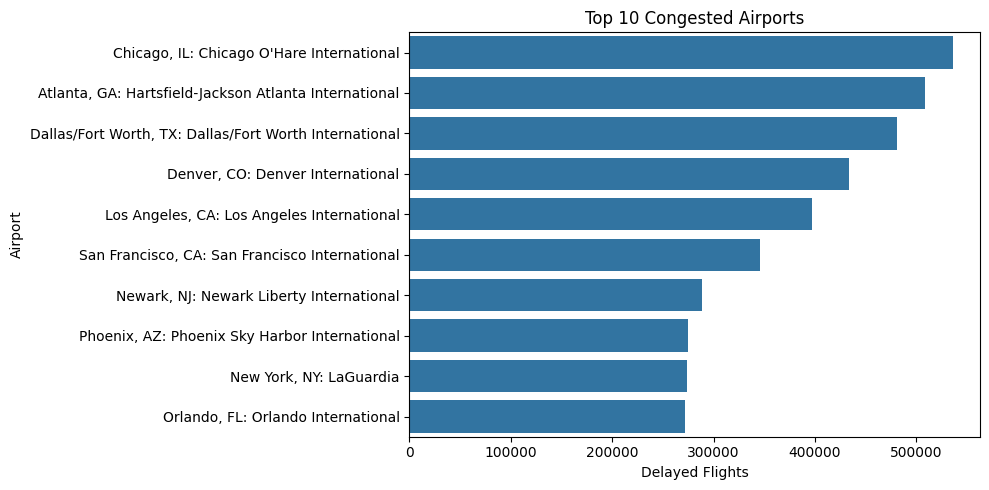

In [18]:

airport = df.groupby("airport_name")["number_of_flights_delayed"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=airport.values, y=airport.index)
plt.title("Top 10 Congested Airports")
plt.xlabel("Delayed Flights")
plt.ylabel("Airport")
plt.tight_layout()
plt.show()

# Monthly Delay Rate Distribution


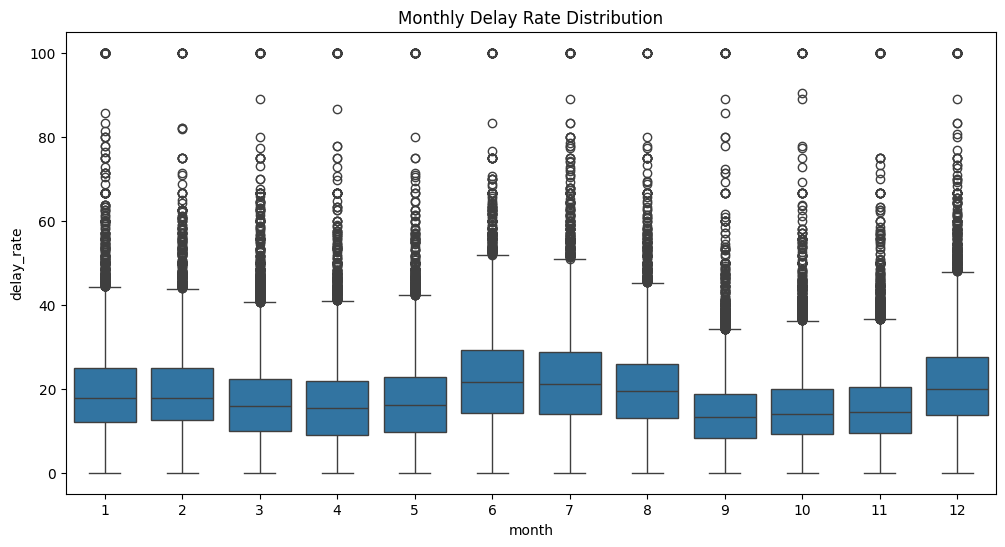

In [19]:

plt.figure(figsize=(12,6))
sns.boxplot(
    x='month',
    y='delay_rate',
    data=df
)

plt.title('Monthly Delay Rate Distribution')
plt.show()

# Airline Performance Score Comparison

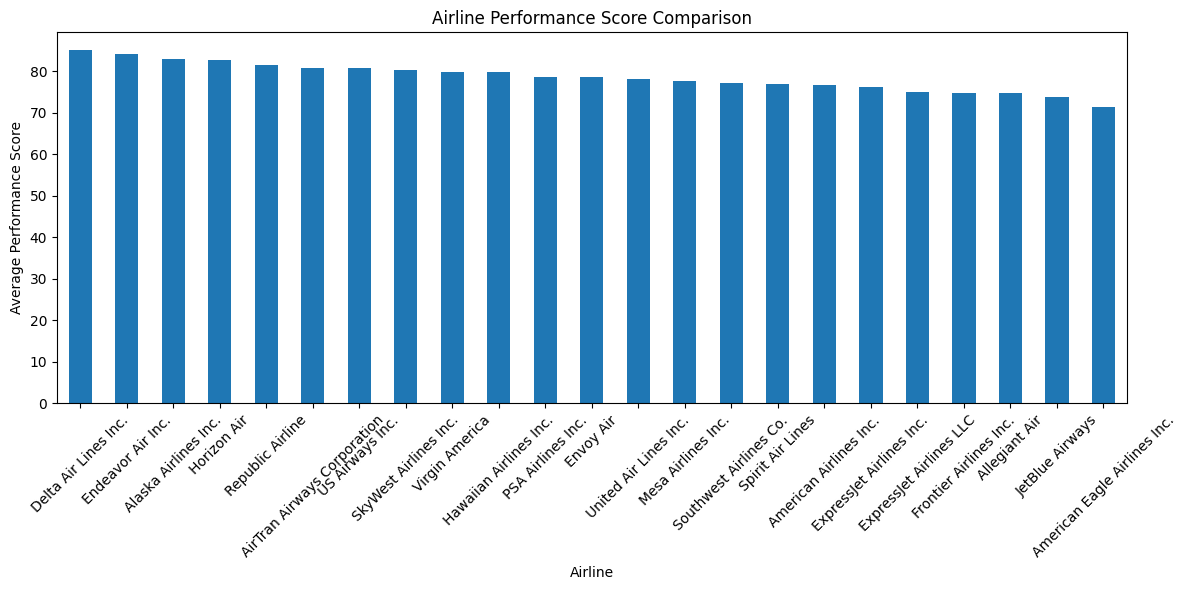

In [20]:
# Average performance score by airline
airline_performance = (
    df.groupby("carrier_name")["performance_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

airline_performance.plot(
    kind="bar"
)

plt.title("Airline Performance Score Comparison")
plt.xlabel("Airline")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cancellation rate of Airline

<Axes: xlabel='carrier_name'>

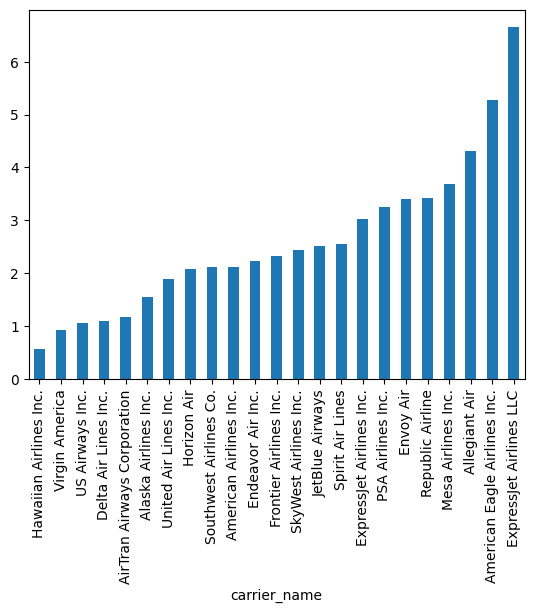

In [21]:
df.groupby("carrier_name")["cancellation_rate"]\
.mean()\
.sort_values()\
.plot(kind="bar")

# Diversion Rate of Airline

<Axes: xlabel='carrier_name'>

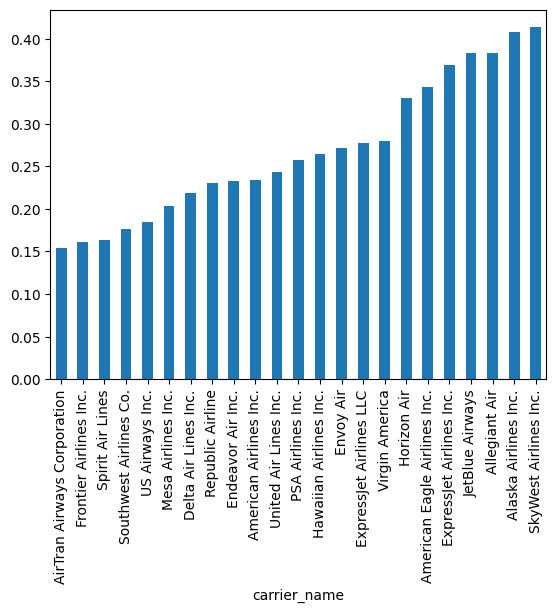

In [22]:
df.groupby("carrier_name")["diversion_rate"]\
.mean()\
.sort_values()\
.plot(kind="bar")

# Top 10 Airports by Total Arrival Delay

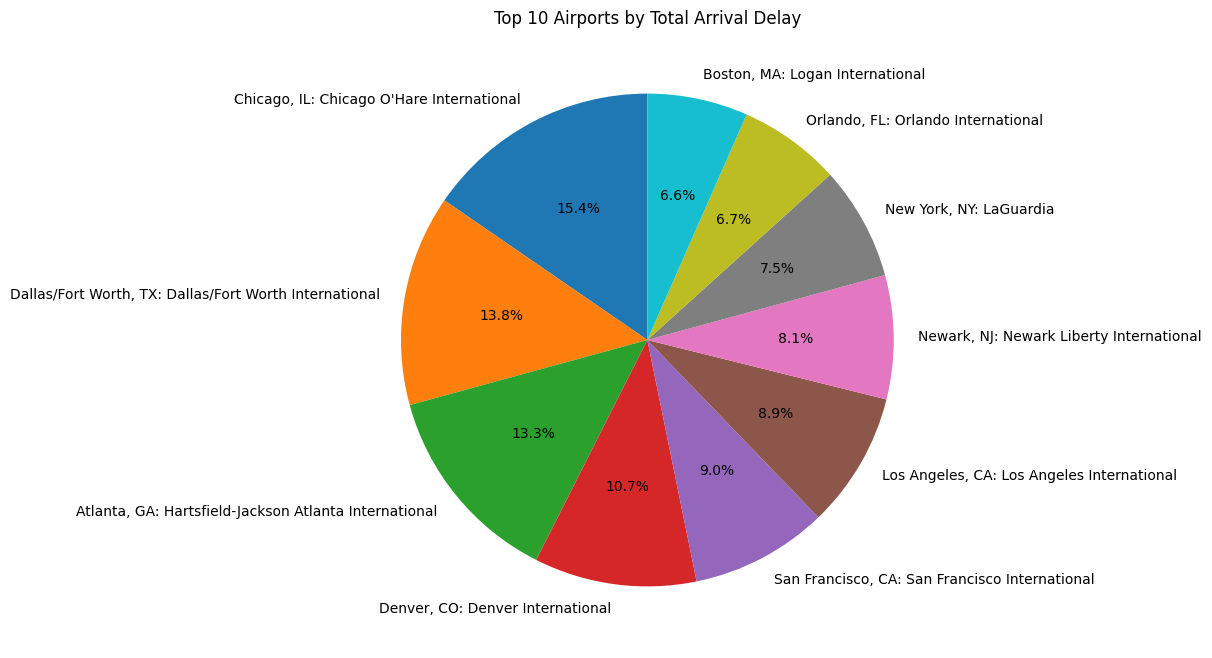

In [23]:
airport_delay = (
    df.groupby("airport_name")["total_arrival_delay"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(8,8))

plt.pie(
    airport_delay,
    labels=airport_delay.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Airports by Total Arrival Delay")

plt.show()

# Airports by Flight Cancellations

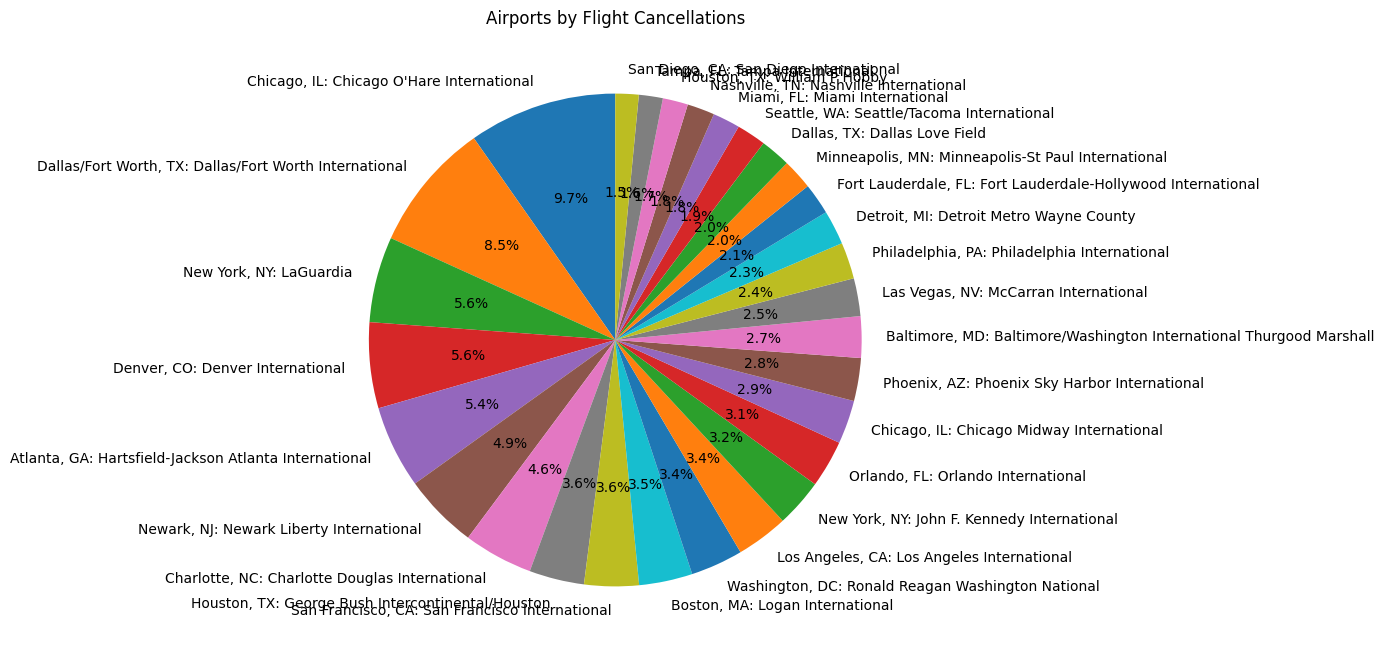

In [24]:
airport_cancel = (
    df.groupby("airport_name")["number_of_flights_canceled"]
      .sum()
      .sort_values(ascending=False)
      .head(29)
)

plt.figure(figsize=(8,8))

plt.pie(
    airport_cancel,
    labels=airport_cancel.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Airports by Flight Cancellations")

plt.show()

# Arriving Flights vs Total Arrival Delay

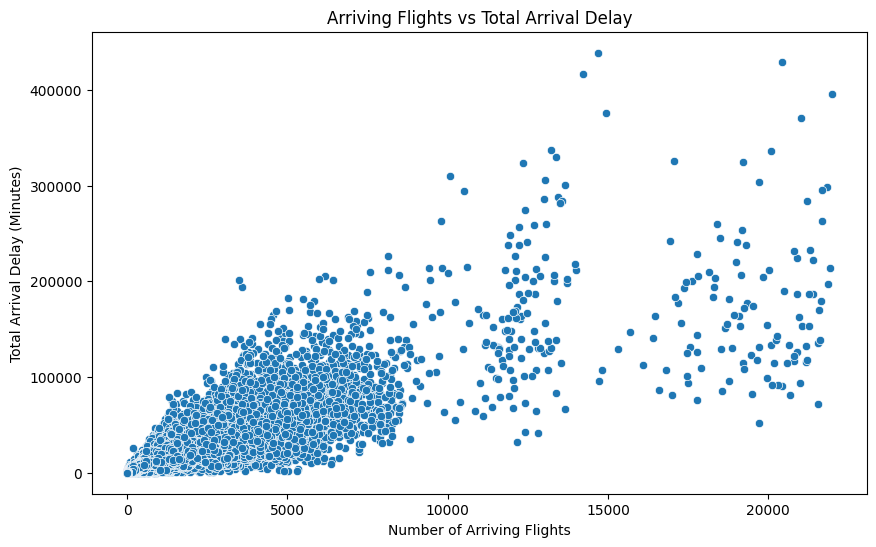

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='number_of_arriving_flights',
    y='total_arrival_delay'
)

plt.title('Arriving Flights vs Total Arrival Delay')
plt.xlabel('Number of Arriving Flights')
plt.ylabel('Total Arrival Delay (Minutes)')
plt.show()

# Delayed Flights vs Cancelled Flights

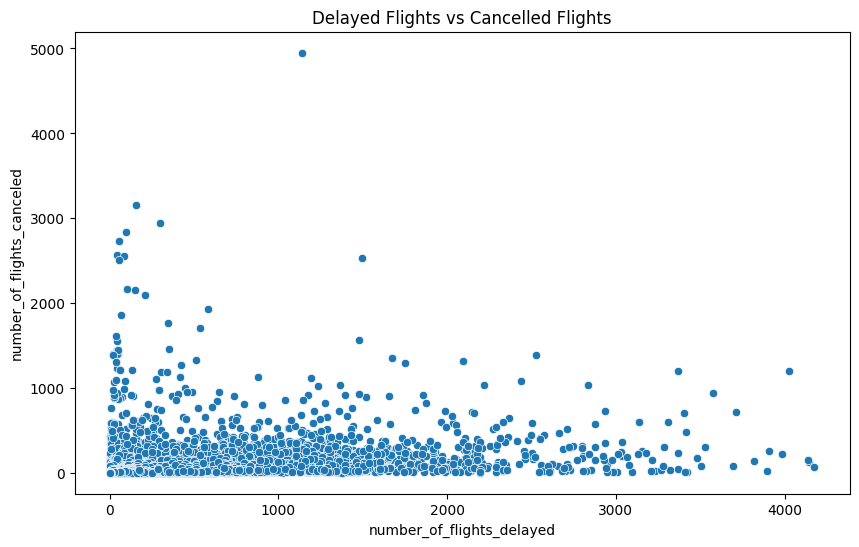

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='number_of_flights_delayed',
    y='number_of_flights_canceled'
)

plt.title('Delayed Flights vs Cancelled Flights')
plt.show()

# Correlation Heatmap

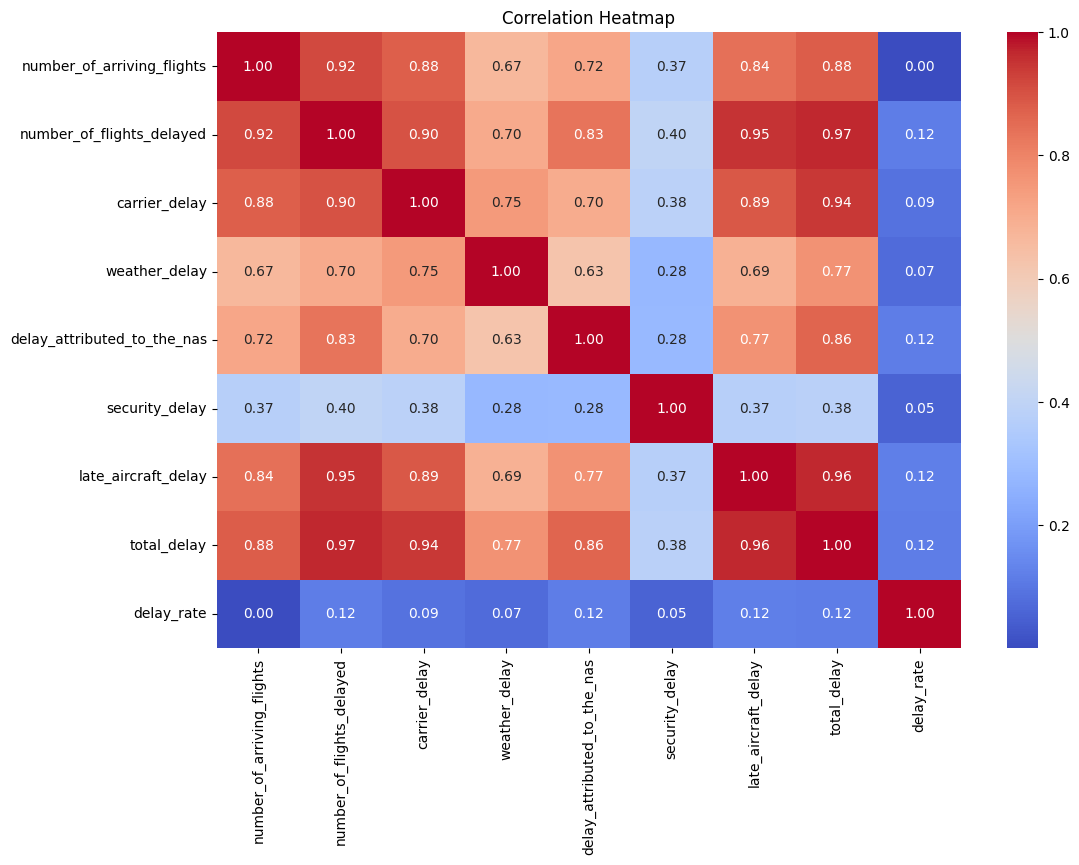

In [27]:
numeric_cols = [
    'number_of_arriving_flights',
    'number_of_flights_delayed',
    'carrier_delay',
    'weather_delay',
    'delay_attributed_to_the_nas',
    'security_delay',
    'late_aircraft_delay',
    'total_delay',
    'delay_rate'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()




# Export the Dataset


In [28]:

df.to_csv("D:\Project\data analysis project 2\Airline_Delay_Cause_analysis.csv")